In [1]:
import pandas as pd
import requests
import math
import os
#from IPython.display import Image, display
from pathlib import Path
import geopandas
from shapely.geometry import box, Polygon, MultiPolygon
from shapely.affinity import affine_transform
from shapely.ops import transform
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO



In [2]:
headers = {
    "accept": "image/*",
    "X-Mapy-Api-Key": "JM310Y0HMX1GZlVWxFTUNjC_KpnLuUbeh0zSBFs10n4"
}


In [3]:

def get_tile_coords(lat_wgs84, lon_wgs84, zoom):
    n = 2**zoom
    x = n * (lon_wgs84 + 180.0) / 360.0
    lat_rad = math.radians(lat_wgs84)
    y = n * (1 - math.log(math.tan(lat_rad) + 1 / math.cos(lat_rad)) / math.pi) / 2

    return int(x), int(y)

def get_resolution_cm_per_pixel(zoom, tile_resolution = 256):
    earth_radius_km = 6370
    earth_circumference_km = 2*math.pi*earth_radius_km
    n_tiles = 2**zoom
    resolution_cm = 1000*100*earth_circumference_km / (n_tiles * tile_resolution)
    return resolution_cm



In [4]:
z = 18
x_coords, y_coords = 50.119670, 14.455259
x, y = get_tile_coords(x_coords, y_coords,z)


response = requests.get(f"https://api.mapy.cz/v1/maptiles/aerial/256/{z}/{x}/{y}", headers=headers)


In [6]:

polygons_path = r"C:\Users\Matous\Desktop\Projects\Parking spaces\Data\Parkovani_praha.geojson"
polygons = geopandas.read_file(polygons_path)


In [7]:

def get_tile_bounding_box(lat_wgs84, lon_wgs84, zoom):
    x, y = get_tile_coords(lat_wgs84, lon_wgs84, zoom)
    n = 2**zoom

    min_lon = 360*x / n - 180
    max_lon = 360*(x+1) / n - 180
    min_lat = math.degrees(math.atan(math.sinh(math.pi * (1 - 2 * (y + 1) / n))))
    max_lat = math.degrees(math.atan(math.sinh(math.pi * (1 - 2 * y / n))))

    return min_lon, min_lat, max_lon, max_lat


min_lon, min_lat, max_lon, max_lat = get_tile_bounding_box(x_coords, y_coords,z)

tile_bounding_box = box(min_lon, min_lat, max_lon, max_lat)

intersecting_polygons = []

for i, poly in enumerate(polygons.geometry):
    if i % 10000 == 0:
        print(f"Searching {i}-th polygon")
    intersection = poly.intersection(tile_bounding_box)
    if not intersection.is_empty:
        intersecting_polygons.append(intersection)



print("Tile Bounding Box:", (min_lon, min_lat, max_lon, max_lat))
print("Number of intersecting polygons:", len(intersecting_polygons))



Searching 0-th polygon
Searching 10000-th polygon
Searching 20000-th polygon
Searching 30000-th polygon
Searching 40000-th polygon
Searching 50000-th polygon
Searching 60000-th polygon
Tile Bounding Box: (14.453887939453125, 50.11881702842052, 14.45526123046875, 50.119697571288164)
Number of intersecting polygons: 13


In [8]:
polygons

,name,folders,description,altitude,alt_mode,time_begin,time_end,time_when,geometry
0,Mnohoúhelník bez názvu,Moje místa,,0.0,absolute,,,,"MULTIPOLYGON Z (((14.42661 50.03765 0, 14.4277..."
1,Mnohoúhelník bez názvu,Moje místa,,0.0,absolute,,,,"MULTIPOLYGON Z (((14.42833 50.03795 0, 14.4283..."
2,Mnohoúhelník bez názvu,Moje místa,,0.0,absolute,,,,"MULTIPOLYGON Z (((14.42819 50.03764 0, 14.4281..."
3,Mnohoúhelník bez názvu,Moje místa,,0.0,absolute,,,,"MULTIPOLYGON Z (((14.42556 50.03639 0, 14.4255..."
4,Mnohoúhelník bez názvu,Moje místa,,0.0,absolute,,,,"MULTIPOLYGON Z (((14.42343 50.0367 0, 14.42405..."
...,...,...,...,...,...,...,...,...,...
62696,Mnohoúhelník bez názvu,Moje místa,,0.0,absolute,,,,"MULTIPOLYGON Z (((14.49571 50.06027 0, 14.4950..."
62697,Mnohoúhelník bez názvu,Moje místa,,0.0,absolute,,,,"MULTIPOLYGON Z (((14.49604 50.0608 0, 14.49605..."
62698,Mnohoúhelník bez názvu,Moje místa,,0.0,absolute,,,,"MULTIPOLYGON Z (((14.49568 50.06076 0, 14.4954..."
62699,Mnohoúhelník bez názvu,Moje místa,,0.0,absolute,,,,"MULTIPOLYGON Z (((14.49726 50.06094 0, 14.4972..."


[<POLYGON Z ((3.128 200.014 0, 48.582 199.663 0, 47.03 204.686 0, 0 206.26 0,...>, <POLYGON Z ((0.428 217.394 0, 56.927 218.127 0, 131.798 222.636 0, 228.259 2...>, <POLYGON Z ((244.736 237.558 0, 244.439 232.854 0, 256 233.512 0, 256 238.22...>, <POLYGON Z ((232.439 223.829 0, 232.517 217.025 0, 256 218.813 0, 256 225.35...>, <POLYGON Z ((120.608 10.666 0, 8.212 0 0, 66.385 0 0, 145.529 7.901 0, 256 1...>, <POLYGON Z ((202.25 215.821 0, 199.945 220.993 0, 123.599 211.476 0, 124.711...>, <POLYGON Z ((3.128 200.014 0, 48.582 199.663 0, 47.03 204.686 0, 0 206.26 0,...>, <POLYGON Z ((0.428 217.394 0, 56.927 218.127 0, 131.798 222.636 0, 228.259 2...>, <POLYGON Z ((244.736 237.558 0, 244.439 232.854 0, 256 233.512 0, 256 238.22...>, <POLYGON Z ((232.439 223.829 0, 232.517 217.025 0, 256 218.813 0, 256 225.35...>, <POLYGON Z ((120.608 10.666 0, 8.212 0 0, 66.385 0 0, 145.529 7.901 0, 256 1...>, <POLYGON Z ((202.25 215.821 0, 199.945 220.993 0, 123.599 211.476 0, 124.711...>, <POLYGON Z ((21

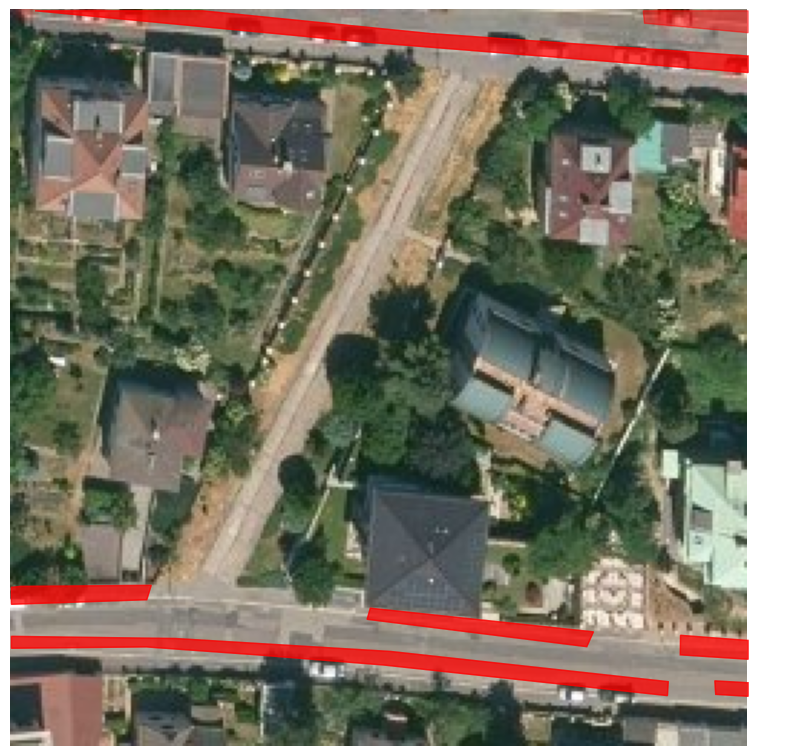

In [11]:
tile_image = Image.open(BytesIO(response.content))  # Replace with your image source
tile_width, tile_height = tile_image.size

def get_transfomation(img_width, img_height, min_lon, min_lat, max_lon, max_lat):
    scale_x = img_width / (max_lon - min_lon)
    scale_y = img_height / (max_lat - min_lat)
    scale_y_inv = -scale_y

    x_offset = -min_lon * scale_x
    y_offset = max_lat * scale_y

    return (scale_x, 0, 0, scale_y_inv, x_offset, y_offset)

img_polys = []

for poly in intersecting_polygons:
    img_polys.append(affine_transform(poly, get_transfomation(tile_width, tile_height, min_lon, min_lat, max_lon, max_lat)))

print(img_polys)

fig, ax = plt.subplots(figsize = (10,10))
ax.imshow(tile_image)

for img_poly in img_polys:
    if img_poly.geom_type == 'MultiPolygon':
        for poly in img_poly.geoms:
            x, y = poly.exterior.xy
            ax.fill(x, y, color='red', alpha=0.5)
    else:
        x, y = img_poly.exterior.xy
        ax.fill(x, y, color='red', alpha=0.5)

ax.set_axis_off()
plt.show()


In [27]:
response.content

b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x05\x03\x04\x04\x04\x03\x05\x04\x04\x04\x05\x05\x05\x06\x07\x0c\x08\x07\x07\x07\x07\x0f\x0b\x0b\t\x0c\x11\x0f\x12\x12\x11\x0f\x11\x11\x13\x16\x1c\x17\x13\x14\x1a\x15\x11\x11\x18!\x18\x1a\x1d\x1d\x1f\x1f\x1f\x13\x17"$"\x1e$\x1c\x1e\x1f\x1e\xff\xdb\x00C\x01\x05\x05\x05\x07\x06\x07\x0e\x08\x08\x0e\x1e\x14\x11\x14\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\x1e\xff\xc0\x00\x11\x08\x01\x00\x01\x00\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1c\x00\x00\x02\x03\x00\x03\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x05\x06\x03\x04\x07\x01\x02\x08\x00\xff\xc4\x00E\x10\x00\x02\x01\x02\x05\x02\x04\x04\x03\x05\x05\x07\x04\x01\x05\x00\x01\x02\x03\x04\x11\x00\x05\x12!1\x06A\x13"Qa\x07q\x81\x91\x142\xa1\x15#BR\xb1\x08\xc1\xd1\xe1\xf0\x163br\x82\xa2\xf1$4C\x92%D